In [53]:
# Libraries importation
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import shap
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim 

from scipy.stats.mstats import winsorize 
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer, TVAESynthesizer
from sdmetrics.reports.single_table import QualityReport
from sdmetrics.single_table import NewRowSynthesis
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
 
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importing the data
weather_df = pd.read_csv(r"C:\Users\DELL\Deployment\final_year_project\Weather.csv")

In [3]:
# To check the first 5 rows
weather_df.head()

,Year,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m
0,2010,33.55,14.20,0.0,26.13,2.92
1,2010,33.37,13.49,0.0,23.75,3.11
2,2010,32.23,12.44,0.0,22.46,3.36
3,2010,32.74,12.34,0.0,25.80,1.91
4,2010,32.37,13.90,0.0,30.21,1.67


In [4]:
# To check the details about the data
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5845 entries, 0 to 5844
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   5845 non-null   int64  
 1   T2m_Max                5845 non-null   float64
 2   T2m_Min                5845 non-null   float64
 3   Precipitation          5845 non-null   float64
 4   Relative_humidity_2_m  5845 non-null   float64
 5   Wind_speed_2_m         5845 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 274.1 KB


In [5]:
# Looking for missing values
missing_values = weather_df.isna().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [6]:
# Checking for duplicates
weather_df.duplicated().sum()

0

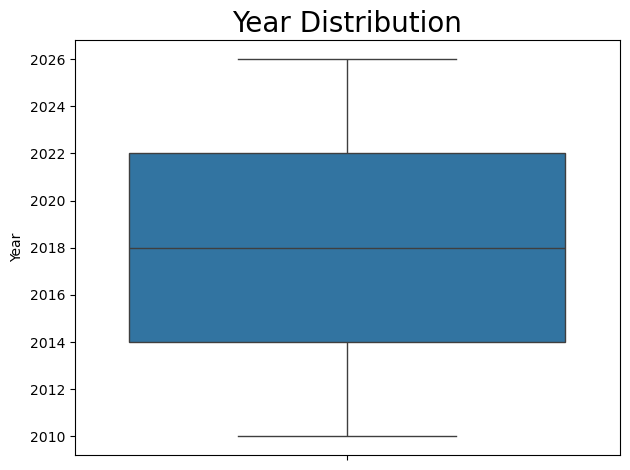

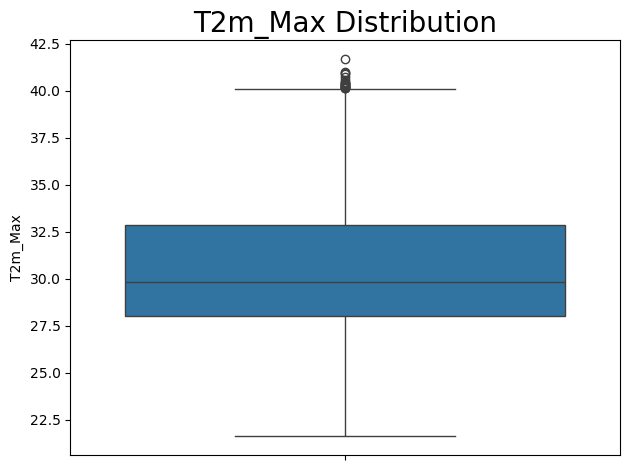

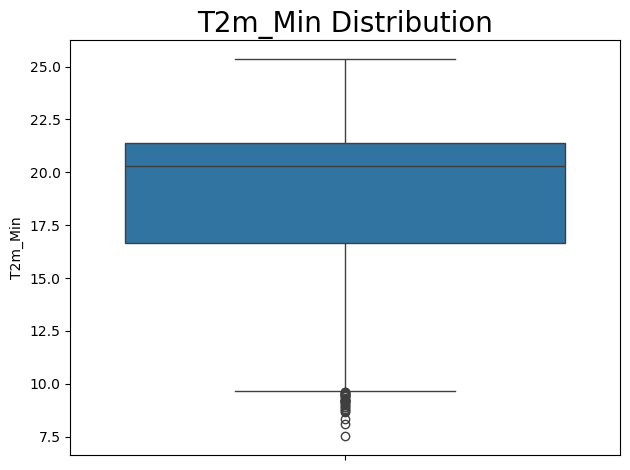

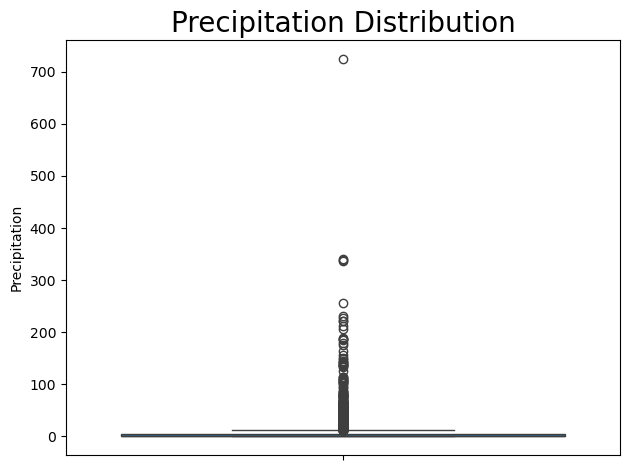

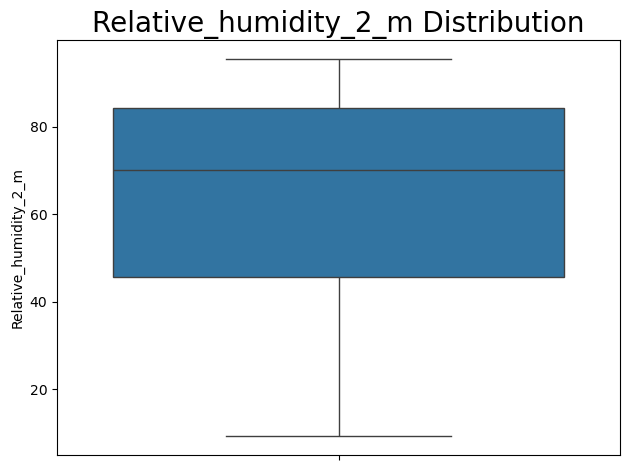

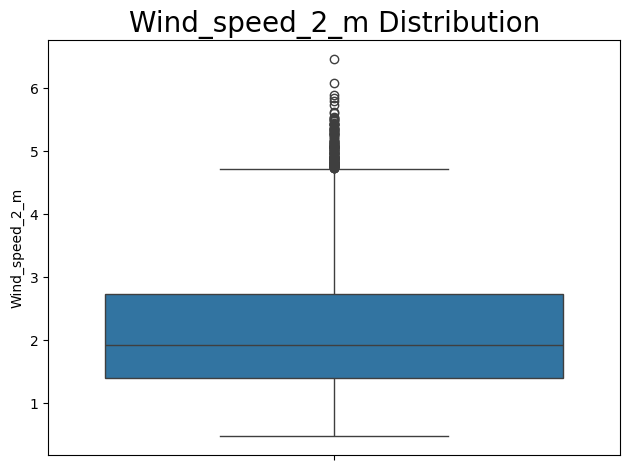

In [7]:
# Looking for outliers
for col in weather_df.columns:
    sns.boxplot(weather_df[col], orient = 'x')
    plt.title(f'{col} Distribution', fontsize = 20, y = 1.0)
    plt.tight_layout()
    plt.show()

In [8]:
for col in ['T2m_Max', 'T2m_Min', 'Precipitation', 'Wind_speed_2_m']:
    weather_df[col] = winsorize(weather_df[col], limits = [0.05, 0.05])

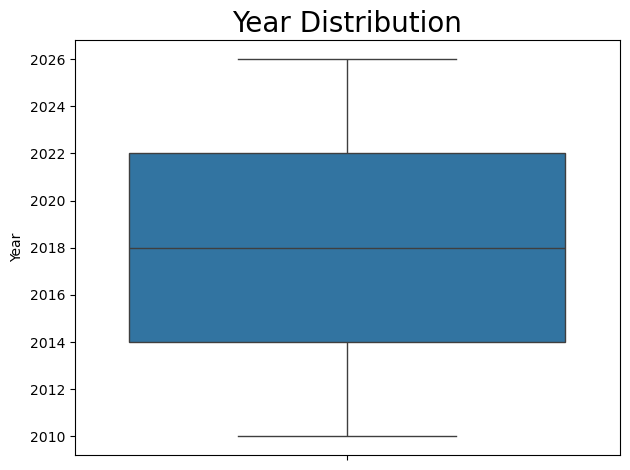

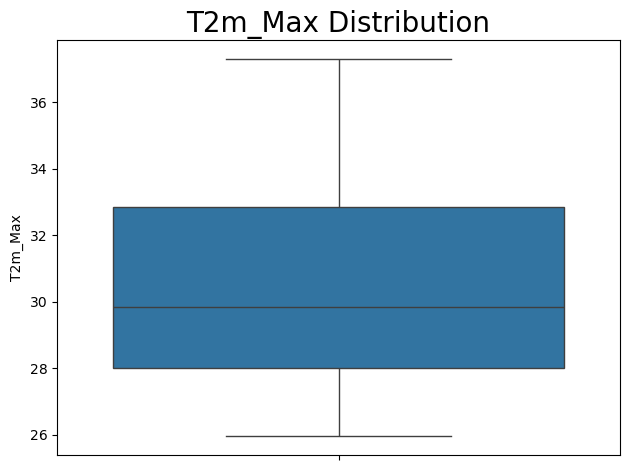

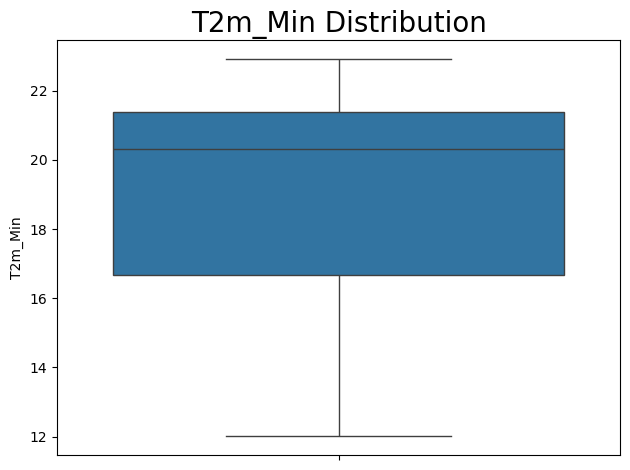

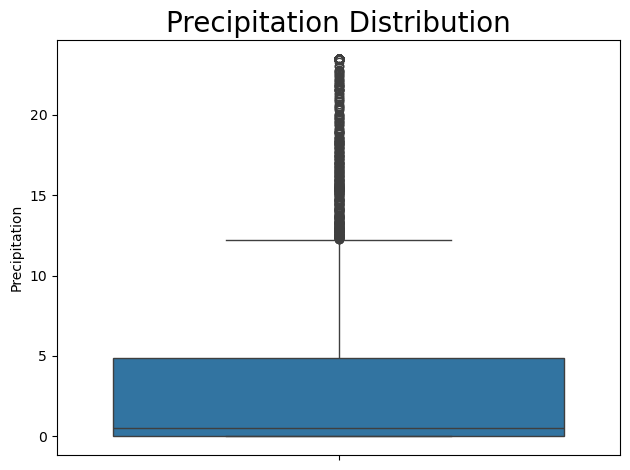

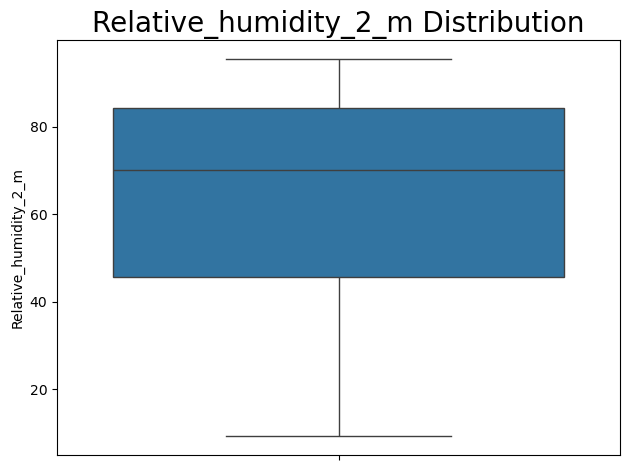

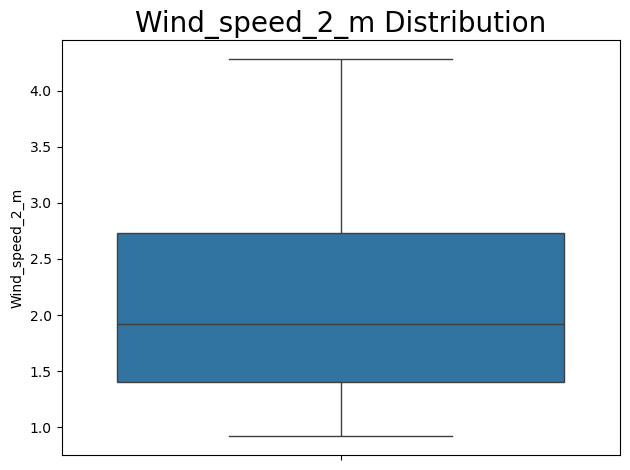

In [9]:
for col in weather_df.columns:
    sns.boxplot(weather_df[col], orient = 'x')
    plt.title(f'{col} Distribution', fontsize = 20, y = 1.0)
    plt.tight_layout()
    plt.show()

In [10]:
weather_df.describe()

,Year,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m
count,5845.000000,5845.000000,5845.000000,5845.000000,5845.000000,5845.000000
mean,2017.501796,30.586821,19.005141,3.852972,64.147406,2.154364
std,4.611038,3.289785,3.262933,6.288309,22.488362,0.958824
min,2010.000000,25.950000,12.010000,0.000000,9.190000,0.920000
25%,2014.000000,28.000000,16.680000,0.000000,45.580000,1.400000
50%,2018.000000,29.850000,20.300000,0.510000,70.140000,1.920000
75%,2022.000000,32.850000,21.370000,4.900000,84.290000,2.730000
max,2026.000000,37.290000,22.910000,23.460000,95.430000,4.280000


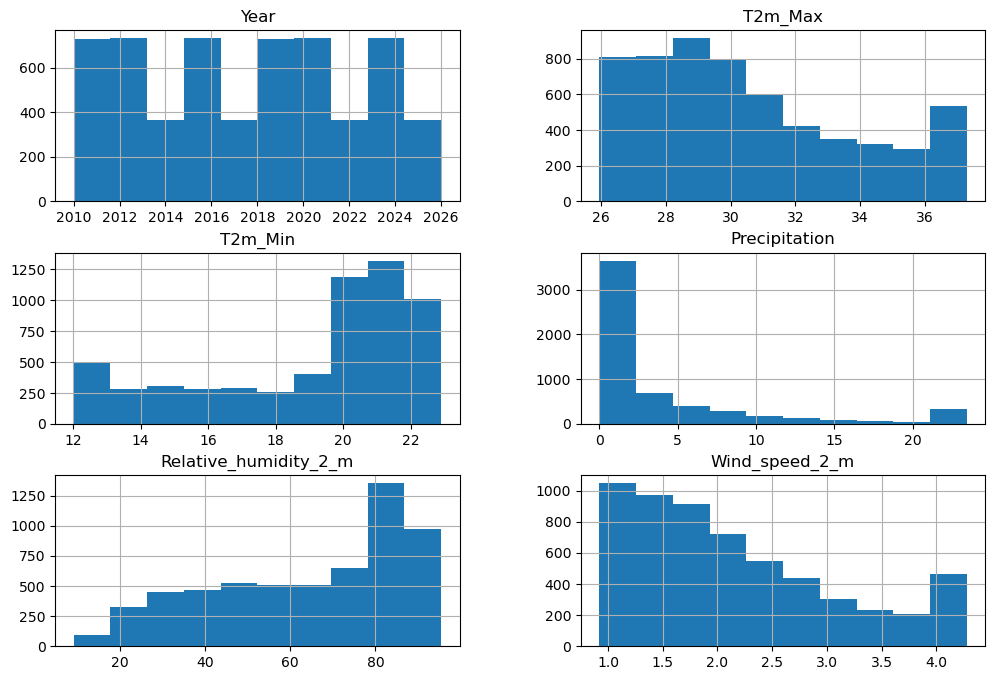

In [11]:
weather_df.hist(figsize = (12,8))
plt.show()

In [12]:
# Log Transformation for the skewed column
weather_df["Precipitation_log"] = np.log1p(weather_df["Precipitation"])

In [13]:
df_yearly = weather_df.groupby("Year").agg({
    "T2m_Max": "mean", "T2m_Min": "mean",
    "Precipitation": "sum","Relative_humidity_2_m": "mean", 
    "Wind_speed_2_m": "mean"}).reset_index()

In [14]:
df_yearly

,Year,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m
0,2010,31.085534,19.600603,1217.50,62.411205,2.135041
1,2011,31.282904,18.792740,1051.59,59.460603,2.172685
2,2012,30.363388,18.925301,1653.60,63.799098,2.139180
3,2013,31.604110,19.352795,734.67,62.167260,2.011836
4,2014,31.558932,19.624356,1176.85,59.349397,2.117370
5,2015,31.135068,19.172575,1342.28,58.344685,2.339781
6,2016,30.292240,18.972432,1495.63,65.996093,2.067049
7,2017,30.567014,18.884301,1403.12,63.010082,2.134411
8,2018,30.523425,18.987945,1320.49,64.491233,2.069370
9,2019,30.790329,19.322493,1283.56,63.853096,2.090603


In [16]:
yield_df = pd.read_csv(r"C:\Users\DELL\Deployment\final_year_project\KADA_CROP2.csv")

In [17]:
yield_df.head()

,Crop,Year,Area (hectares),Yield,Output (tonnes)
0,Cassava,2011,39669.22,8.00,317353.75
1,Yam,2011,65974.96,8.27,471338.31
2,Cocoyam,2011,1469.57,5.00,7347.83
3,Sweet potato,2011,11494.62,9.58,110172.07
4,Maize,2011,388189.90,1.86,720924.11


In [18]:
yield_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             104 non-null    object 
 1   Year             104 non-null    int64  
 2   Area (hectares)  104 non-null    float64
 3   Yield            103 non-null    float64
 4   Output (tonnes)  103 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 4.2+ KB


In [19]:
# Merge datasets
yield_weather_df = pd.merge(yield_df, weather_df, on = 'Year', how = 'inner')


In [20]:
# Drop non-predictive columns
cols_to_drop = ["Year", "Area (hectares)", "Yield", "Output (tonnes)"]
yield_weather_df.drop(columns = [c for c in cols_to_drop if c in yield_weather_df.columns], inplace = True)


In [41]:
yield_weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37989 entries, 0 to 37988
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Crop                   37989 non-null  object 
 1   T2m_Max                37989 non-null  float64
 2   T2m_Min                37989 non-null  float64
 3   Precipitation          37989 non-null  float64
 4   Relative_humidity_2_m  37989 non-null  float64
 5   Wind_speed_2_m         37989 non-null  float64
 6   Precipitation_log      37989 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.0+ MB


In [21]:
np.random.seed(42)
samples = len(yield_weather_df)

# Water source distribution
water_sources = ["Rainfed", "Irrigation", "Borehole"]
water_probs = [0.6, 0.3, 0.1]
Water_Source = np.random.choice(water_sources, size = samples, p = water_probs)

In [22]:
Distance_to_Water_km = []

for source in Water_Source:
    
    # Distance depends on water source
    if source == "Rainfed":
        Distance_to_Water_km.append(np.random.uniform(3, 10))
        
    elif source == "Irrigation":
        Distance_to_Water_km.append(np.random.uniform(0.5, 3))
        
    else:  # Borehole
        Distance_to_Water_km.append(np.random.uniform(0.5, 5))

Distance_to_Water_km = np.array(Distance_to_Water_km)

In [23]:
# Soil moisture depends on water source
Soil_Moisture = []

for source in Water_Source:
    if source == "Rainfed":
        Soil_Moisture.append(np.random.normal(22, 6))
    elif source == "Irrigation":
        Soil_Moisture.append(np.random.normal(35, 5))
    else:
        Soil_Moisture.append(np.random.normal(30, 6))

Soil_Moisture = np.clip(Soil_Moisture, 5, 50)

In [24]:
# Semi-independent soil chemistry
Soil_pH = np.clip(np.random.normal(6.2, 0.4, samples), 5.0, 7.5)
Nitrogen = np.clip(np.random.normal(35, 10, samples), 10, 70)
Phosphorus = np.clip(np.random.normal(20, 7, samples), 5, 50)
Potassium = np.clip(np.random.normal(150, 30, samples), 80, 250)

In [25]:
soil_water_df = pd.DataFrame({
    "Soil_pH": Soil_pH,
    "Nitrogen_mgkg": Nitrogen,
    "Phosphorus_mgkg": Phosphorus,
    "Potassium_mgkg": Potassium,
    "Soil_Moisture_%": Soil_Moisture,
    "Distance_to_Water_km": Distance_to_Water_km,
    "Water_Source": Water_Source
})

In [26]:
soil_water_df.head()

,Soil_pH,Nitrogen_mgkg,Phosphorus_mgkg,Potassium_mgkg,Soil_Moisture_%,Distance_to_Water_km,Water_Source
0,5.953713,47.398135,30.379174,176.256041,33.229792,4.840484,Rainfed
1,5.454015,36.970527,27.388718,110.554996,39.983235,2.326320,Borehole
2,6.720548,19.620025,26.984220,120.263452,41.709079,0.793618,Irrigation
3,5.920228,51.353020,25.542609,187.593928,24.843879,3.916349,Rainfed
4,6.408331,24.275088,19.566327,207.783375,26.278166,8.604605,Rainfed


In [27]:
# Reset indices before concatenation to ensure row alignment
yield_weather_df.reset_index(drop = True, inplace = True)
soil_water_df.reset_index(drop = True, inplace = True)

In [28]:
# Concatenate the dataframes horizontally
full_df = pd.concat([yield_weather_df, soil_water_df], axis = 1)

In [29]:
# Remove missing values
full_df = full_df.dropna().reset_index(drop = True)

In [30]:
full_df.head()

,Crop,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m,Precipitation_log,Soil_pH,Nitrogen_mgkg,Phosphorus_mgkg,Potassium_mgkg,Soil_Moisture_%,Distance_to_Water_km,Water_Source
0,Cassava,29.65,12.01,0.0,44.35,3.65,0.0,5.953713,47.398135,30.379174,176.256041,33.229792,4.840484,Rainfed
1,Cassava,30.48,13.36,0.0,47.11,2.42,0.0,5.454015,36.970527,27.388718,110.554996,39.983235,2.326320,Borehole
2,Cassava,31.61,14.47,0.0,50.10,2.09,0.0,6.720548,19.620025,26.984220,120.263452,41.709079,0.793618,Irrigation
3,Cassava,31.23,15.52,0.0,49.39,2.58,0.0,5.920228,51.353020,25.542609,187.593928,24.843879,3.916349,Rainfed
4,Cassava,30.98,14.25,0.0,45.30,2.93,0.0,6.408331,24.275088,19.566327,207.783375,26.278166,8.604605,Rainfed


In [31]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37989 entries, 0 to 37988
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Crop                   37989 non-null  object 
 1   T2m_Max                37989 non-null  float64
 2   T2m_Min                37989 non-null  float64
 3   Precipitation          37989 non-null  float64
 4   Relative_humidity_2_m  37989 non-null  float64
 5   Wind_speed_2_m         37989 non-null  float64
 6   Precipitation_log      37989 non-null  float64
 7   Soil_pH                37989 non-null  float64
 8   Nitrogen_mgkg          37989 non-null  float64
 9   Phosphorus_mgkg        37989 non-null  float64
 10  Potassium_mgkg         37989 non-null  float64
 11  Soil_Moisture_%        37989 non-null  float64
 12  Distance_to_Water_km   37989 non-null  float64
 13  Water_Source           37989 non-null  object 
dtypes: float64(12), object(2)
memory usage: 4.1+ MB


In [32]:
# Looking for missing values
missing_values = full_df.isna().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [33]:
# Checking for duplicates
full_df.duplicated().sum()

0

In [34]:
full_num_cols = full_df.select_dtypes(["int", "float"]).columns

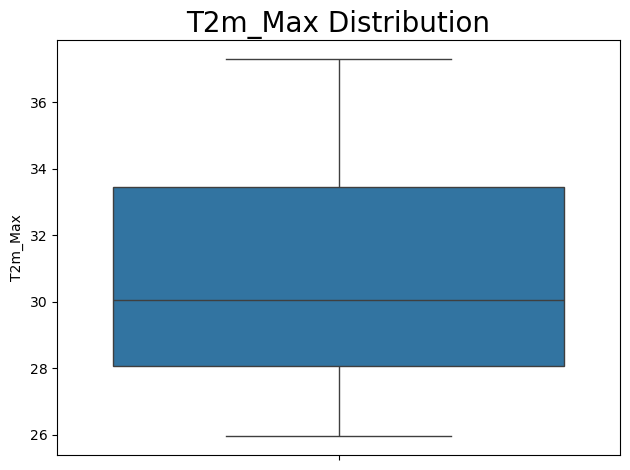

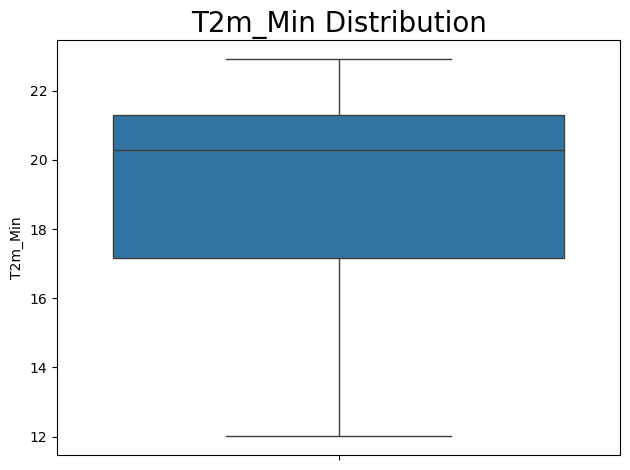

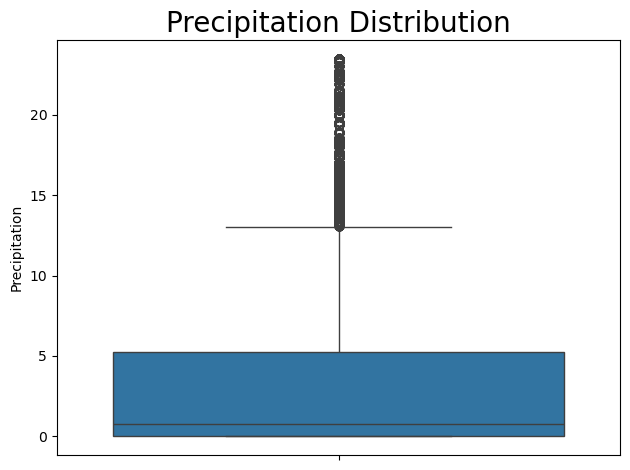

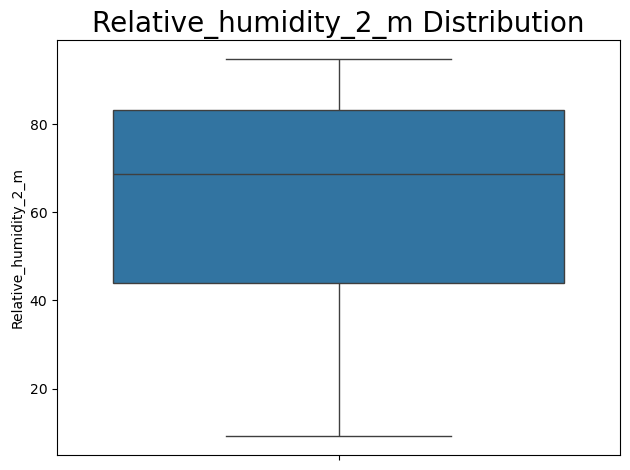

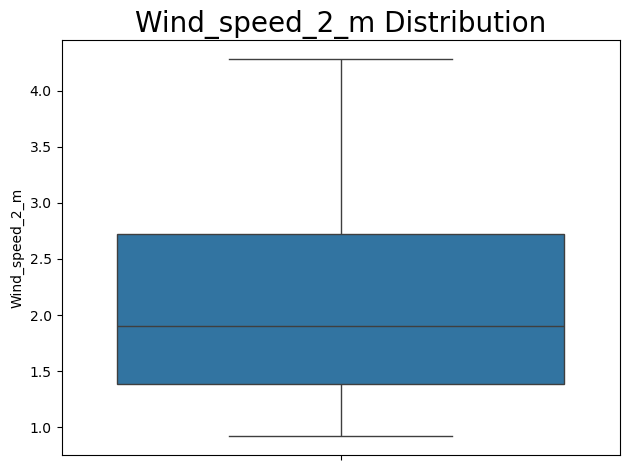

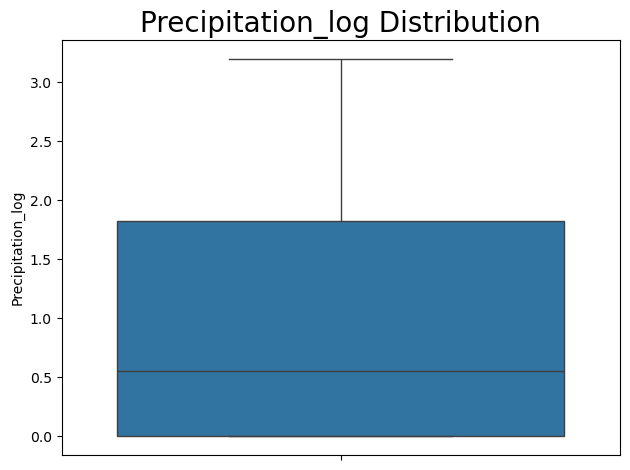

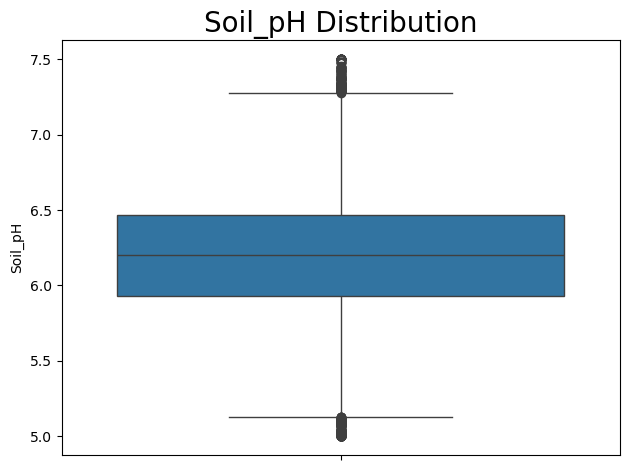

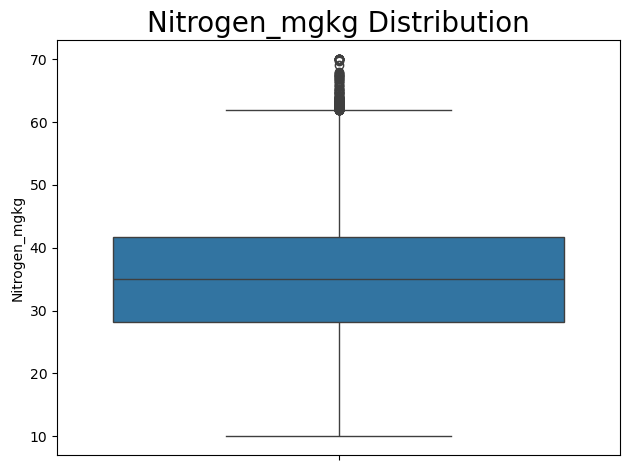

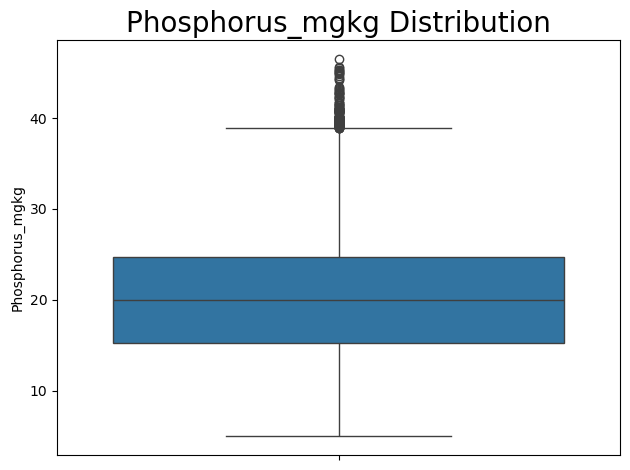

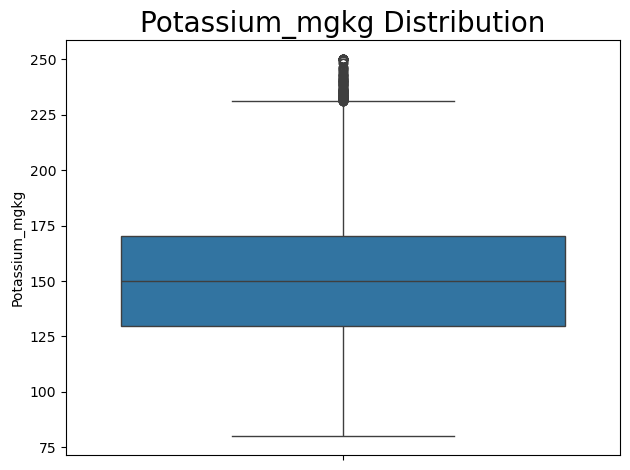

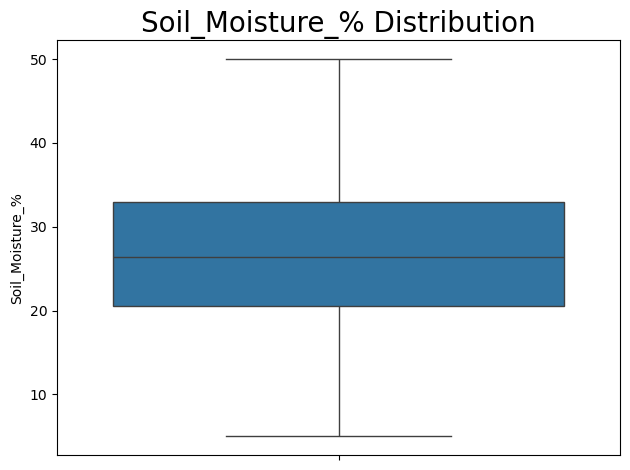

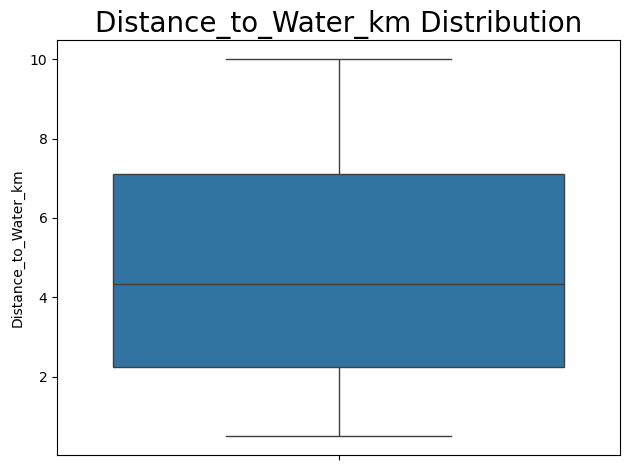

In [35]:
# Looking for outliers
for col in full_num_cols:
    sns.boxplot(full_df[col], orient = 'x')
    plt.title(f'{col} Distribution', fontsize = 20, y = 1.0)
    plt.tight_layout()
    plt.show()

In [36]:
for col in full_num_cols:
    full_df[col] = winsorize(full_df[col], limits = [0.10, 0.10])

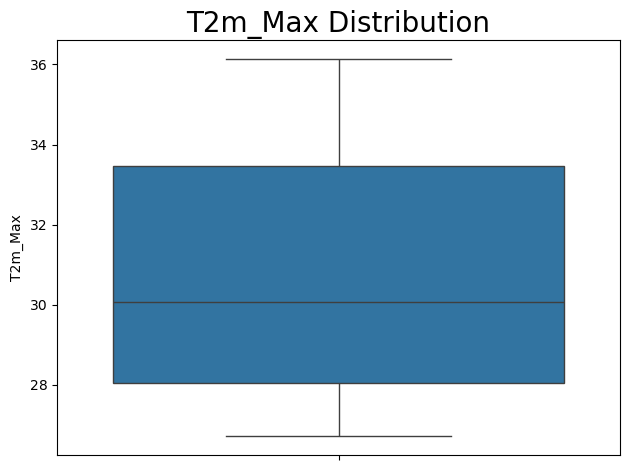

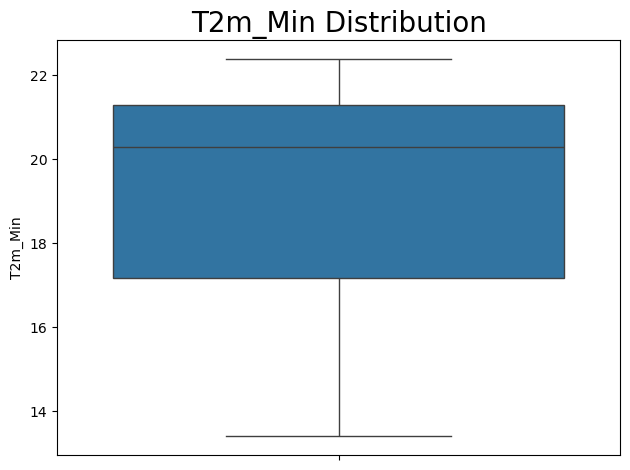

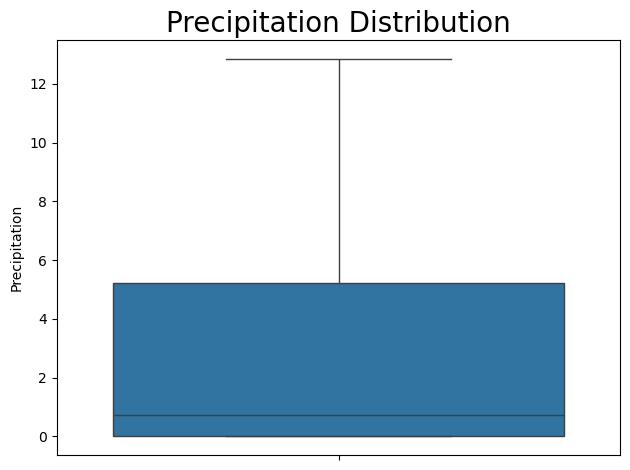

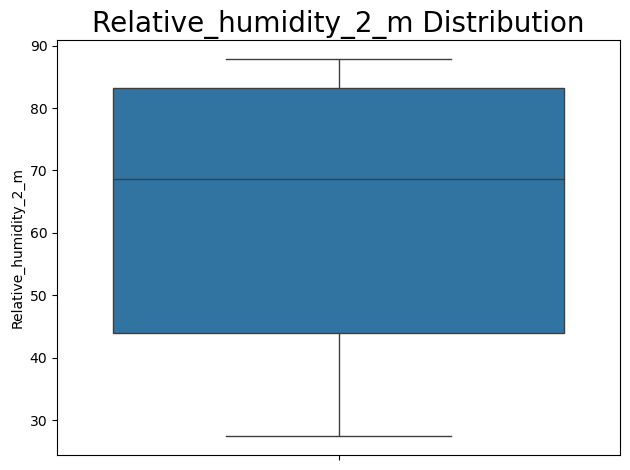

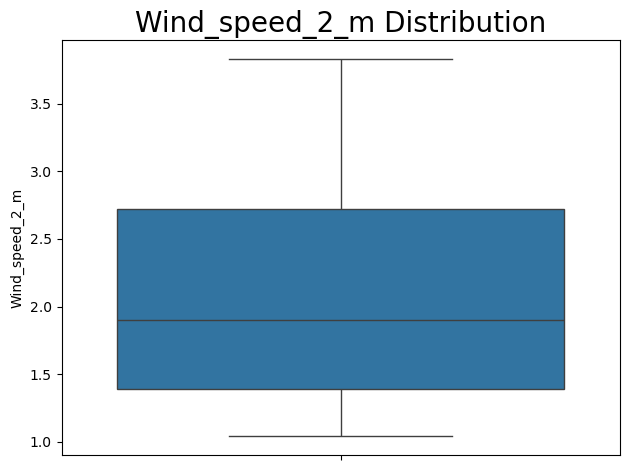

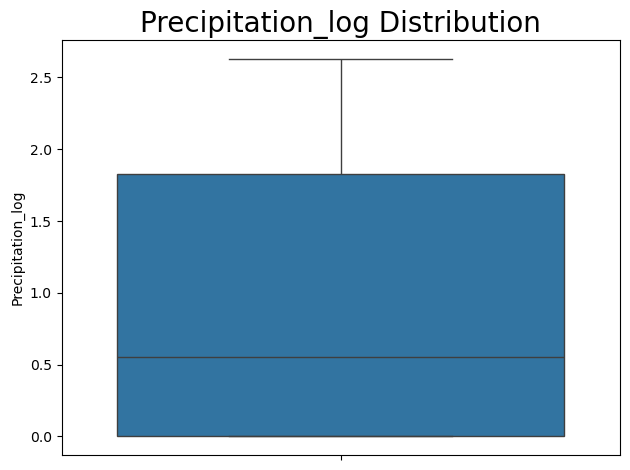

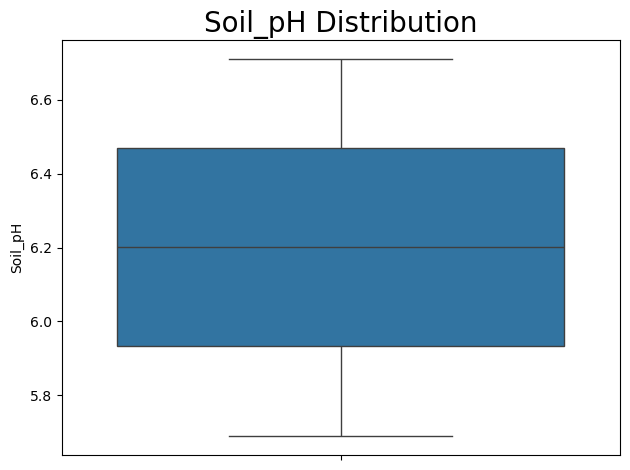

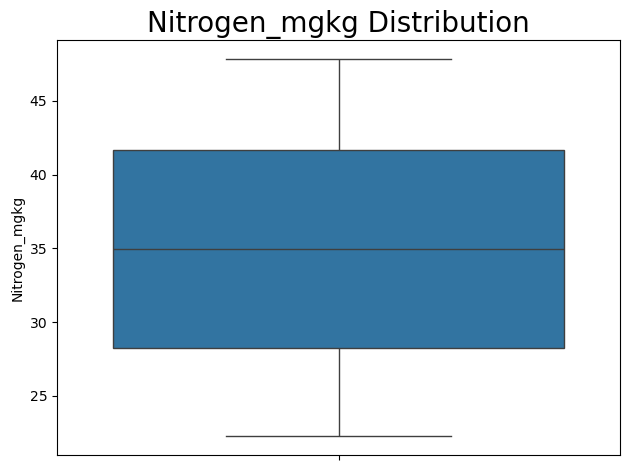

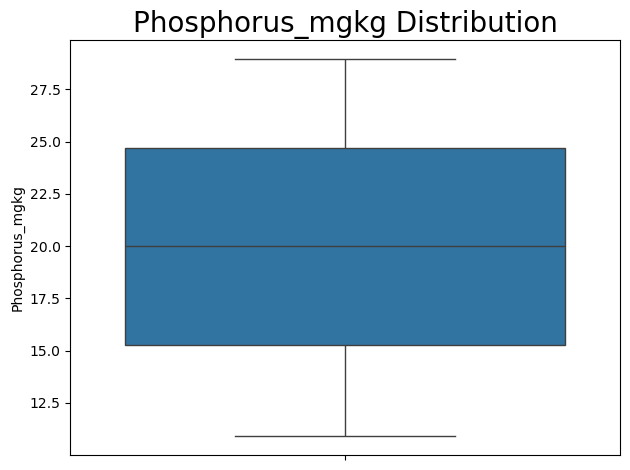

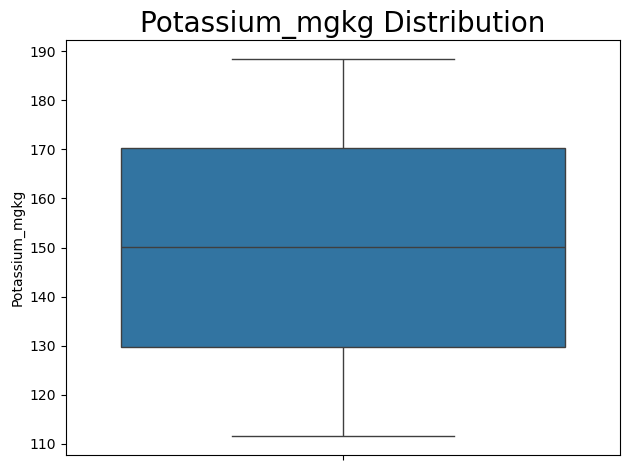

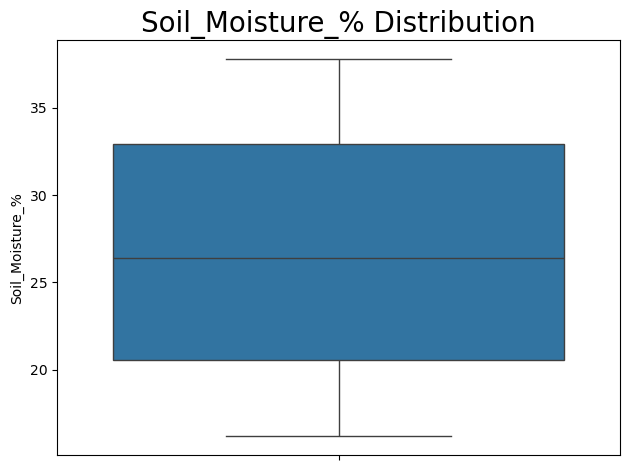

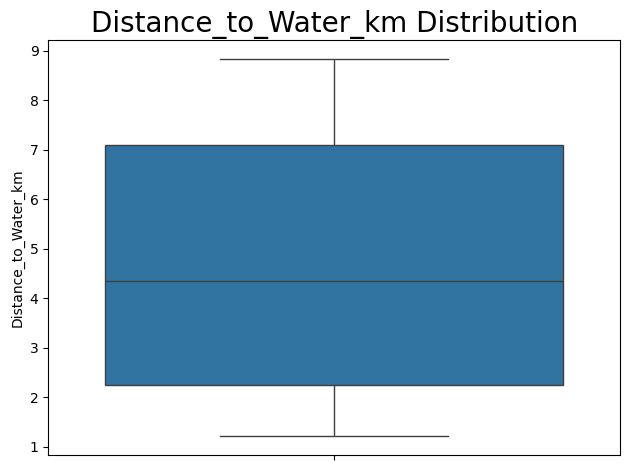

In [37]:
# Looking for outliers
for col in full_num_cols:
    sns.boxplot(full_df[col], orient = 'x')
    plt.title(f'{col} Distribution', fontsize = 20, y = 1.0)
    plt.tight_layout()
    plt.show()

In [38]:
full_df.describe()

,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m,Precipitation_log,Soil_pH,Nitrogen_mgkg,Phosphorus_mgkg,Potassium_mgkg,Soil_Moisture_%,Distance_to_Water_km
count,37989.000000,37989.000000,37989.000000,37989.000000,37989.000000,37989.000000,37989.000000,37989.000000,37989.000000,37989.000000,37989.000000,37989.000000
mean,30.773389,19.120578,3.226722,63.190037,2.126176,0.927482,6.200871,34.998123,19.972762,149.992673,26.730439,4.682385
std,3.150038,2.961824,4.380905,21.326323,0.896861,0.996832,0.328258,8.215247,5.794025,24.702180,7.140660,2.632642
min,26.720000,13.400000,0.000000,27.400000,1.040000,0.000000,5.688586,22.261958,10.906529,111.554701,16.198297,1.212260
25%,28.050000,17.160000,0.000000,43.930000,1.390000,0.000000,5.932151,28.253995,15.265489,129.716984,20.572387,2.253701
50%,30.060000,20.290000,0.740000,68.610000,1.900000,0.553885,6.201314,34.947258,20.005379,150.006344,26.384742,4.341472
75%,33.460000,21.300000,5.220000,83.190000,2.720000,1.827770,6.469625,41.697327,24.719308,170.261411,32.949868,7.099986
max,36.130000,22.380000,12.840000,87.830000,3.830000,2.627563,6.710493,47.832485,28.949305,188.355128,37.775863,8.828426


In [39]:
numeric_df = full_df.select_dtypes(include = ['number'])
corr_matrix = numeric_df.corr().round(2)
corr_matrix

,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m,Precipitation_log,Soil_pH,Nitrogen_mgkg,Phosphorus_mgkg,Potassium_mgkg,Soil_Moisture_%,Distance_to_Water_km
T2m_Max,1.00,0.11,-0.54,-0.70,0.18,-0.55,0.0,0.00,0.00,-0.01,0.00,-0.01
T2m_Min,0.11,1.00,0.43,0.52,-0.57,0.55,0.0,0.00,-0.00,0.01,-0.00,-0.00
Precipitation,-0.54,0.43,1.00,0.69,-0.42,0.95,-0.0,-0.00,-0.00,0.01,-0.00,0.01
Relative_humidity_2_m,-0.70,0.52,0.69,1.00,-0.63,0.81,-0.0,-0.00,0.00,0.01,-0.00,0.00
Wind_speed_2_m,0.18,-0.57,-0.42,-0.63,1.00,-0.51,0.0,-0.00,-0.01,-0.01,0.01,-0.01
Precipitation_log,-0.55,0.55,0.95,0.81,-0.51,1.00,-0.0,-0.00,-0.00,0.01,-0.00,0.00
Soil_pH,0.00,0.00,-0.00,-0.00,0.00,-0.00,1.0,-0.00,0.00,-0.00,-0.00,-0.00
Nitrogen_mgkg,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.0,1.00,-0.00,-0.00,-0.01,0.01
Phosphorus_mgkg,0.00,-0.00,-0.00,0.00,-0.01,-0.00,0.0,-0.00,1.00,0.00,0.00,-0.00
Potassium_mgkg,-0.01,0.01,0.01,0.01,-0.01,0.01,-0.0,-0.00,0.00,1.00,-0.01,0.01


In [40]:
crop_counts = full_df["Crop"].value_counts()
crop_counts

Crop
Tomato          2557
Yam             2557
Ginger          2557
Onion           2557
Maize           2557
Sorghum         2557
Rice            2557
Ground nut      2557
Cowpea          2557
Soyabean        2557
Cassava         2191
Sugar cane      1826
Acha            1461
Millet          1461
Garden egg      1461
Okra            1461
Sweet potato     731
Cotton           731
Cocoyam          731
Pepper           365
Name: count, dtype: int64

In [42]:
categorical_columns = full_df.select_dtypes("object").columns

In [43]:
encoder = LabelEncoder()
for col in categorical_columns:
    full_df[col] = encoder.fit_transform(full_df[[col]])

In [44]:
full_df.head()

,Crop,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m,Precipitation_log,Soil_pH,Nitrogen_mgkg,Phosphorus_mgkg,Potassium_mgkg,Soil_Moisture_%,Distance_to_Water_km,Water_Source
0,1,29.65,13.40,0.0,44.35,3.65,0.0,5.953713,47.398135,28.949305,176.256041,33.229792,4.840484,2
1,1,30.48,13.40,0.0,47.11,2.42,0.0,5.688586,36.970527,27.388718,111.554701,37.775863,2.326320,0
2,1,31.61,14.47,0.0,50.10,2.09,0.0,6.710493,22.261958,26.984220,120.263452,37.775863,1.212260,1
3,1,31.23,15.52,0.0,49.39,2.58,0.0,5.920228,47.832485,25.542609,187.593928,24.843879,3.916349,2
4,1,30.98,14.25,0.0,45.30,2.93,0.0,6.408331,24.275088,19.566327,188.355128,26.278166,8.604605,2


In [46]:
X = full_df.drop(columns = ["Crop"])
y = full_df["Crop"]

In [47]:
feature_names = X.columns.tolist()
print(feature_names)

['T2m_Max', 'T2m_Min', 'Precipitation', 'Relative_humidity_2_m', 'Wind_speed_2_m', 'Precipitation_log', 'Soil_pH', 'Nitrogen_mgkg', 'Phosphorus_mgkg', 'Potassium_mgkg', 'Soil_Moisture_%', 'Distance_to_Water_km', 'Water_Source']


In [48]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, stratify = y, test_size = 0.2, random_state = 42)
print(f"X_train shape : {X_train_val.shape}, X_test shape : {X_test.shape}, y_train shpe : {y_train_val.shape}, y_test shape : {y_test.shape}")

X_train shape : (30391, 13), X_test shape : (7598, 13), y_train shpe : (30391,), y_test shape : (7598,)


In [49]:
# Second split: Train and Validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, stratify = y_train_val,
    test_size = 0.25,  # 0.25 of 0.8 = 0.2
    random_state = 42)

In [50]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (22793, 13)
Validation: (7598, 13)
Test: (7598, 13)


In [51]:
num_cols = [
'T2m_Max','T2m_Min','Precipitation','Relative_humidity_2_m',
'Wind_speed_2_m','Soil_pH','Nitrogen_mgkg','Phosphorus_mgkg',
'Potassium_mgkg', 'Soil_Moisture_%',
'Distance_to_Water_km'
]

In [55]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

In [57]:
# Fit scaler on training numerical data only
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])

# Transform validation and test
X_val_scaled[num_cols] = scaler.transform(X_val[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [60]:
print("\n--- Training Random Forest Model ---")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)


--- Training Random Forest Model ---


RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

In [61]:

# ============================================================
# 6. PERFORMANCE REPORT
# ============================================================

y_pred = rf_model.predict(X_test_scaled)

print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nDetailed Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


Model Accuracy: 0.0530

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       292
           1       0.01      0.00      0.01       438
           2       0.00      0.00      0.00       146
           3       0.00      0.00      0.00       146
           4       0.07      0.10      0.08       511
           5       0.00      0.00      0.00       292
           6       0.05      0.07      0.06       512
           7       0.06      0.09      0.07       512
           8       0.05      0.08      0.06       511
           9       0.00      0.00      0.00       292
          10       0.00      0.00      0.00       292
          11       0.06      0.10      0.07       512
          12       0.00      0.00      0.00        73
          13       0.05      0.07      0.06       512
          14       0.06      0.08      0.07       512
          15       0.05      0.07      0.06       512
          16       0.04 